In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#### Ingest the data paths

In [2]:
shapes_dir = '.././../../data/shapes'
tree_heights_path = f'{shapes_dir}/tree_height_metrics.shp'
assert os.path.exists(shapes_dir), 'Check your path'

In [3]:
gdf = gpd.read_file(tree_heights_path)

In [4]:
gdf.head()

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,id_col,hmax,h95,hmedian,hmean,hmin,hstd,canopy_pct,height_dis,geometry
0,Naomie Nicodemus Mutuku,121.0,152.0,True,True,NaN,1,6.216919,5.060059,3.915283,3.939713,2.000977,0.616638,92.249224,"(array([ 1099, 10636, 5402, 704]), array([2...","POLYGON ((372831.949 9823702.107, 372851.714 9..."
1,Emma Mutie,150.0,145.0,True,True,Melia volkensii,2,9.342346,6.901657,3.832703,4.039243,2.000305,1.328388,29.630312,"(array([3229, 2588, 378, 241]), array([2.000...","POLYGON ((372578.994 9823944.388, 372594.168 9..."
2,Dorrine Kasyoka Mutua,108.0,115.0,False,True,Melia volkensii,3,5.333618,4.241336,3.171021,3.226729,2.003052,0.619401,32.102729,"(array([1292, 2818, 891, 199]), array([2.003...","POLYGON ((372171.895 9823766.202, 372174.053 9..."
3,Kinyao Musembi,150.0,33.0,False,True,Melia volkensii,4,6.490845,6.282077,3.428680,3.826487,2.001770,1.249858,9.204559,"(array([476, 603, 146, 277]), array([2.00177 ...","POLYGON ((373715.511 9824459.051, 373699.469 9..."
4,Simon Mumo Mulu,150.0,37.0,False,True,Melia volkensii,5,9.216736,8.431592,3.103943,3.743629,2.001465,1.799402,1.663408,"(array([1239, 198, 113, 143]), array([2.001...","POLYGON ((375408.007 9824206.071, 375424.481 9..."


In [5]:
gdf.drop(columns= ['height_dis'], inplace=True)

#### Feature engineering canopy area and crown area
* These are important metrics needed to calculate biomass

In [6]:
gdf['area'] = gdf.geometry.area

In [7]:
gdf.head()

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,id_col,hmax,h95,hmedian,hmean,hmin,hstd,canopy_pct,geometry,area
0,Naomie Nicodemus Mutuku,121.0,152.0,True,True,NaN,1,6.216919,5.060059,3.915283,3.939713,2.000977,0.616638,92.249224,"POLYGON ((372831.949 9823702.107, 372851.714 9...",1190.093943
1,Emma Mutie,150.0,145.0,True,True,Melia volkensii,2,9.342346,6.901657,3.832703,4.039243,2.000305,1.328388,29.630312,"POLYGON ((372578.994 9823944.388, 372594.168 9...",1337.585674
2,Dorrine Kasyoka Mutua,108.0,115.0,False,True,Melia volkensii,3,5.333618,4.241336,3.171021,3.226729,2.003052,0.619401,32.102729,"POLYGON ((372171.895 9823766.202, 372174.053 9...",997.260106
3,Kinyao Musembi,150.0,33.0,False,True,Melia volkensii,4,6.490845,6.282077,3.428680,3.826487,2.001770,1.249858,9.204559,"POLYGON ((373715.511 9824459.051, 373699.469 9...",1004.651683
4,Simon Mumo Mulu,150.0,37.0,False,True,Melia volkensii,5,9.216736,8.431592,3.103943,3.743629,2.001465,1.799402,1.663408,"POLYGON ((375408.007 9824206.071, 375424.481 9...",6265.098817


In [8]:
gdf['canopy_area'] = (gdf['canopy_pct'] * gdf['area'])/100

In [9]:
gdf.sample(10)

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,id_col,hmax,h95,hmedian,hmean,hmin,hstd,canopy_pct,geometry,area,canopy_area
51,Fredrick Mwango Mutava,100.0,81.0,True,True,Melia volkensii,52,6.964966,5.262640,4.125183,4.092301,2.002808,0.738846,92.790280,"POLYGON ((372974.578 9827142.489, 373004.415 9...",993.045282,921.449494
144,Danson Mulonzi Muthama,150.0,86.0,True,True,NaN,145,7.559998,6.627991,3.986267,4.169704,2.002075,1.065307,74.362733,"POLYGON ((372005.8 9823498.726, 372020.604 982...",755.931665,562.131446
42,Musembi Nguue,150.0,114.0,True,False,Melia volkensii,43,11.369568,10.871490,7.381287,6.959188,2.000793,2.706755,7.977276,"POLYGON ((373980.946 9826318.39, 373962.41 982...",2058.493178,164.211685
132,Dancun Mwengi,NaN,NaN,False,True,NaN,133,7.519531,6.707993,4.085114,4.209599,2.003296,1.405024,14.168771,"POLYGON ((371509.071 9823004.325, 371509.6 982...",2218.508157,314.335340
6,Isaac Isika Nduto,150.0,61.0,True,True,NaN,7,6.268188,4.258948,3.121094,3.162204,2.000122,0.680982,41.643685,"POLYGON ((375653.372 9824154.447, 375655.736 9...",781.466768,325.431555
111,Wambua Ngumi,128.0,111.0,False,True,NaN,112,6.161987,4.974274,3.213745,3.301569,2.000549,0.895966,4.026914,"POLYGON ((373944.1 9821668.522, 373969.035 982...",1217.184720,49.014976
62,Dorcas Kavwele,100.0,88.0,True,True,Melia volkensii,63,8.612793,5.999646,3.828430,3.964873,2.000122,1.061256,79.339617,"POLYGON ((373417.29 9827199.333, 373428.819 98...",1116.518796,885.841742
109,Lenna Koki,150.0,NaN,False,False,NaN,110,11.459290,9.849731,4.220032,4.871881,2.000244,2.327385,5.446338,"POLYGON ((374314.701 9817923.042, 374336.456 9...",8986.410141,489.430275
148,John Mutua Mutia,150.0,2.0,False,False,NaN,149,10.697571,8.714084,3.881989,4.536722,2.000000,2.181584,3.333406,"POLYGON ((374589.716 9820832.458, 374704.583 9...",14187.147947,472.915192
124,Beth Titus Kithuku,140.0,115.0,True,True,Melia volkensii,125,7.895447,5.476974,4.270538,4.253001,2.000305,0.838751,92.653783,"POLYGON ((373473.458 9823279.051, 373472.954 9...",1009.436031,935.280668


In [10]:
gdf.dtypes

name                str
trees_give      float64
trees_aliv      float64
melia_only         bool
bounds_ok          bool
species             str
id_col            int64
hmax            float64
h95             float64
hmedian         float64
hmean           float64
hmin            float64
hstd            float64
canopy_pct      float64
geometry       geometry
area            float64
canopy_area     float64
dtype: object

In [11]:
gdf['crown_area'] = gdf['canopy_area']/gdf['trees_aliv']

In [12]:
gdf.sample()

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,id_col,hmax,h95,hmedian,hmean,hmin,hstd,canopy_pct,geometry,area,canopy_area,crown_area
16,Joel Nyamai Mulaa,NaN,NaN,True,True,NaN,17,14.101196,8.616254,6.491821,6.347723,2.000183,1.641999,72.826908,"POLYGON ((373725.075 9824993.406, 373721.944 9...",14339.027462,10442.670369,NaN


<Axes: xlabel='crown_area', ylabel='Count'>

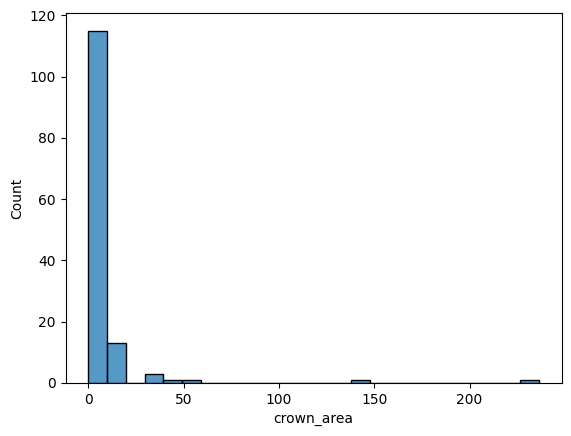

In [13]:
sns.histplot(gdf['crown_area'])

In [14]:
gdf.columns

Index(['name', 'trees_give', 'trees_aliv', 'melia_only', 'bounds_ok',
       'species', 'id_col', 'hmax', 'h95', 'hmedian', 'hmean', 'hmin', 'hstd',
       'canopy_pct', 'geometry', 'area', 'canopy_area', 'crown_area'],
      dtype='str')

In [15]:
gdf['dbh'] = 0.6 * (gdf['hmean'] ** 1.3)

In [16]:
gdf.sample(5)

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,id_col,hmax,h95,hmedian,hmean,hmin,hstd,canopy_pct,geometry,area,canopy_area,crown_area,dbh
7,Esther Nzioka,200.0,76.0,False,True,Melia volkensii,8,6.360413,5.429645,4.612762,4.405921,2.000916,0.804603,54.273699,"POLYGON ((374796.553 9824834.885, 374802.747 9...",1082.826662,587.690079,7.732764,4.124762
23,Wayua Singila,200.0,105.0,True,True,Melia volkensii,24,6.964050,5.912344,4.131592,4.102715,2.000916,1.138189,12.206726,"POLYGON ((372811.963 9825035.752, 372838.221 9...",2639.694125,322.220231,3.068764,3.759621
112,Joshua Mulwa Muyendei,140.0,34.0,False,True,Melia volkensii,113,4.606567,4.367682,3.294861,3.183077,2.002014,0.848918,0.338019,"POLYGON ((374146.938 9821482.021, 374179.855 9...",1147.001915,3.877086,0.114032,2.703041
157,Kathome Farm,NaN,NaN,False,True,NaN,158,21.217651,15.532532,7.889954,8.214359,2.000000,3.646357,86.930487,"POLYGON ((375305.206 9827388.141, 375340.996 9...",37388.645882,32502.131957,NaN,9.270370
158,Mugumo Farm,NaN,NaN,True,True,NaN,159,17.036621,9.955267,5.635590,5.826511,2.000000,2.465690,36.539491,"POLYGON ((373929.198 9826239.74, 373951.433 98...",38849.581067,14195.439368,NaN,5.931744


<Axes: xlabel='dbh', ylabel='Count'>

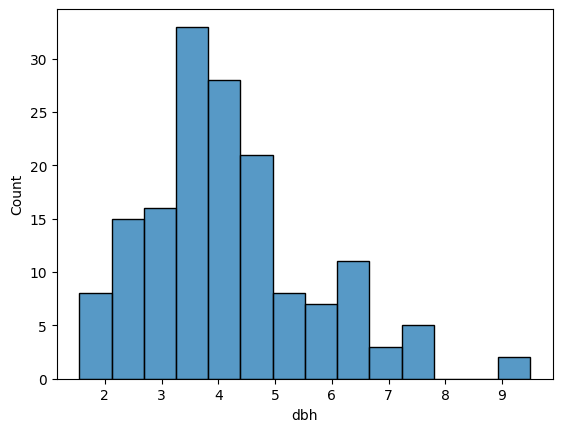

In [17]:
sns.histplot(gdf['dbh'])

In [18]:
gdf['biomass_tree'] = 0.0673 * (0.55 * gdf['dbh']**2 * gdf['hmean']) ** 0.976

In [43]:
gdf['biomass_tree_kuyah'] = 0.25 * (gdf['crown_area'] * gdf['hmean'] ** 0.9)

In [44]:
gdf['kuyah_biomass'] = gdf['biomass_tree_kuyah'] * gdf['trees_aliv']

In [45]:
gdf.head()

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,id_col,hmax,h95,hmedian,...,geometry,area,canopy_area,crown_area,dbh,biomass_tree,chave_biomass,kuyah_biomass,diff,biomass_tree_kuyah
0,Naomie Nicodemus Mutuku,121.0,152.0,True,True,NaN,1,6.216919,5.060059,3.915283,...,"POLYGON ((372831.949 9823702.107, 372851.714 9...",1190.093943,1097.852432,7.222713,3.566607,1.713108,260.392420,942.762127,207.717377,6.202382
1,Emma Mutie,150.0,145.0,True,True,Melia volkensii,2,9.342346,6.901657,3.832703,...,"POLYGON ((372578.994 9823944.388, 372594.168 9...",1337.585674,396.330804,2.733316,3.684183,1.870061,271.158866,348.070964,-79.794085,2.400489
2,Dorrine Kasyoka Mutua,108.0,115.0,False,True,Melia volkensii,3,5.333618,4.241336,3.171021,...,"POLYGON ((372171.895 9823766.202, 372174.053 9...",997.260106,320.147707,2.783893,2.751329,0.849470,97.689072,229.708273,31.326341,1.997463
3,Kinyao Musembi,150.0,33.0,False,True,Melia volkensii,4,6.490845,6.282077,3.428680,...,"POLYGON ((373715.511 9824459.051, 373699.469 9...",1004.651683,92.473761,2.802235,3.433931,1.546276,51.027124,77.353279,-1.837118,2.344039
4,Simon Mumo Mulu,150.0,37.0,False,True,Melia volkensii,5,9.216736,8.431592,3.103943,...,"POLYGON ((375408.007 9824206.071, 375424.481 9...",6265.098817,104.214153,2.816599,3.337582,1.431799,52.976565,85.473263,0.731266,2.310088


In [46]:
gdf.head()

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,id_col,hmax,h95,hmedian,...,geometry,area,canopy_area,crown_area,dbh,biomass_tree,chave_biomass,kuyah_biomass,diff,biomass_tree_kuyah
0,Naomie Nicodemus Mutuku,121.0,152.0,True,True,NaN,1,6.216919,5.060059,3.915283,...,"POLYGON ((372831.949 9823702.107, 372851.714 9...",1190.093943,1097.852432,7.222713,3.566607,1.713108,260.392420,942.762127,207.717377,6.202382
1,Emma Mutie,150.0,145.0,True,True,Melia volkensii,2,9.342346,6.901657,3.832703,...,"POLYGON ((372578.994 9823944.388, 372594.168 9...",1337.585674,396.330804,2.733316,3.684183,1.870061,271.158866,348.070964,-79.794085,2.400489
2,Dorrine Kasyoka Mutua,108.0,115.0,False,True,Melia volkensii,3,5.333618,4.241336,3.171021,...,"POLYGON ((372171.895 9823766.202, 372174.053 9...",997.260106,320.147707,2.783893,2.751329,0.849470,97.689072,229.708273,31.326341,1.997463
3,Kinyao Musembi,150.0,33.0,False,True,Melia volkensii,4,6.490845,6.282077,3.428680,...,"POLYGON ((373715.511 9824459.051, 373699.469 9...",1004.651683,92.473761,2.802235,3.433931,1.546276,51.027124,77.353279,-1.837118,2.344039
4,Simon Mumo Mulu,150.0,37.0,False,True,Melia volkensii,5,9.216736,8.431592,3.103943,...,"POLYGON ((375408.007 9824206.071, 375424.481 9...",6265.098817,104.214153,2.816599,3.337582,1.431799,52.976565,85.473263,0.731266,2.310088


In [47]:
gdf[['chave_biomass', 'kuyah_biomass']].corr()

,chave_biomass,kuyah_biomass
chave_biomass,1.000000,0.773186
kuyah_biomass,0.773186,1.000000


In [48]:
def plot_agreement(df, col_a, col_b):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=df, x=col_a, y=col_b, alpha=0.6)
    
    # Add the 1:1 "Perfect Agreement" Line
    max_val = max(df[[col_a, col_b]].max())
    min_val = min(df[[col_a, col_b]].min())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, ls='--', label='1:1 Line')
    
    plt.title(f'Agreement: {col_a} vs {col_b}')
    plt.legend()
    plt.show()

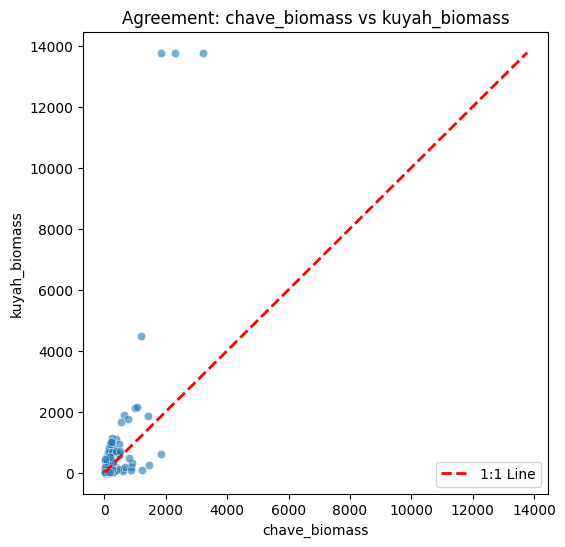

In [49]:
plot_agreement(gdf, 'chave_biomass', 'kuyah_biomass')

In [50]:
def plot_distributions(df, col_a, col_b):
    plt.figure(figsize=(8, 5))
    sns.kdeplot(df[col_a], fill=True, label=col_a)
    sns.kdeplot(df[col_b], fill=True, label=col_b)
    plt.title('Biomass Distribution Comparison')
    plt.legend()
    plt.show()

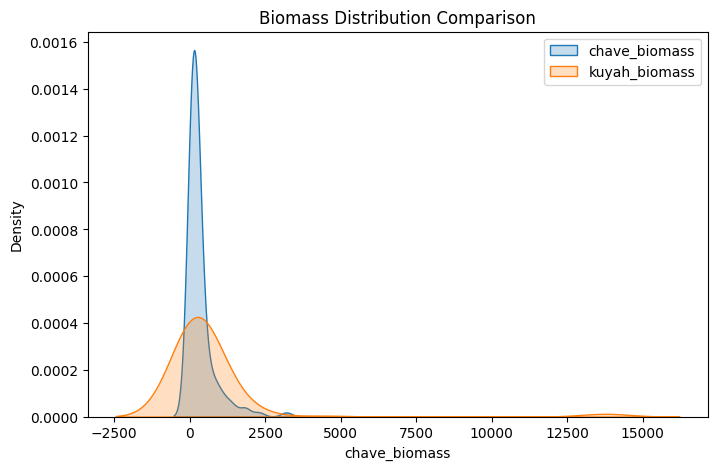

In [69]:
plot_distributions(gdf, 'chave_biomass', 'kuyah_biomass')

In [52]:
from scipy import stats

def run_comparison_stats(df, col_a, col_b):
    # Paired T-test for mean difference
    df = df.dropna()
    _, p_val = stats.ttest_rel(df[col_a], df[col_b])
    # R-Squared for strength of relationship
    r_sq = df[col_a].corr(df[col_b])**2
    # Mean Absolute Error (MAE) for average magnitude of error
    mae = (df[col_a] - df[col_b]).abs().mean()
    
    print(f"R-Squared: {r_sq:.4f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Paired T-test P-value: {p_val:.4e}")

# Example usage:
# run_comparison_stats(df, 'Method_A', 'Method_B')

In [53]:
run_comparison_stats(gdf, 'chave_biomass', 'kuyah_biomass')

R-Squared: 0.6529
Mean Absolute Error: 581.10
Paired T-test P-value: 5.9807e-02


<Axes: ylabel='kuyah_biomass'>

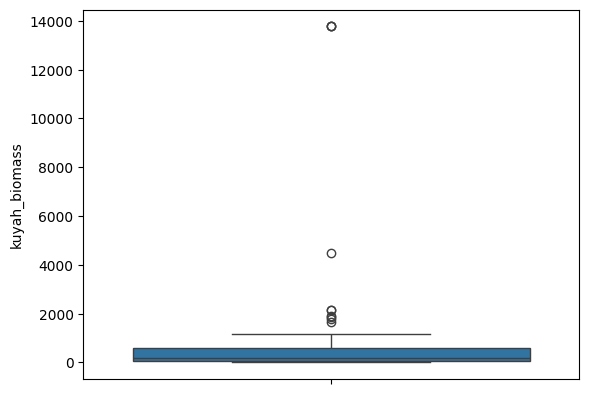

In [56]:
sns.boxplot(gdf['kuyah_biomass'])

In [67]:
gdf['diff'] = gdf['kuyah_biomass'] - gdf['chave_biomass']

<Axes: xlabel='diff', ylabel='Count'>

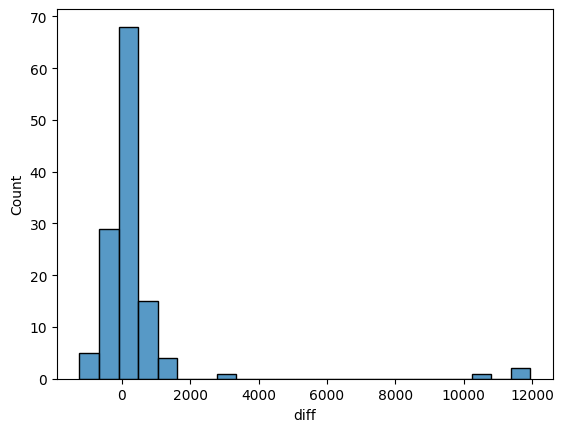

In [68]:
sns.histplot(gdf['diff'])

In [70]:
max(gdf['kuyah_biomass'])

13775.511976857744

In [60]:
gdf[gdf['kuyah_biomass'] == 13775.511976857744]

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,id_col,hmax,h95,hmedian,...,geometry,area,canopy_area,crown_area,dbh,biomass_tree,chave_biomass,kuyah_biomass,diff,biomass_tree_kuyah
15,Rose Martha Mulaa,350.0,350.0,True,True,Melia volkensii,16,14.101196,8.616254,6.491821,...,"POLYGON ((373725.075 9824993.406, 373721.944 9...",14339.027462,10442.670369,29.836201,6.630627,9.154588,3204.105625,13775.511977,10571.406351,39.358606


In [62]:
gdf.drop(columns= ['biomass_tree', 'id_col', 'biomass_tree_kuyah', 'crown_area', 'dbh', 'diff', 'area'], inplace=True)

In [63]:
gdf.columns

Index(['name', 'trees_give', 'trees_aliv', 'melia_only', 'bounds_ok',
       'species', 'hmax', 'h95', 'hmedian', 'hmean', 'hmin', 'hstd',
       'canopy_pct', 'geometry', 'canopy_area', 'chave_biomass',
       'kuyah_biomass'],
      dtype='str')

In [72]:
gdf = gdf[['name', 'trees_give', 'trees_aliv', 'melia_only', 'bounds_ok',
       'species', 'hmax', 'h95', 'hmedian', 'hmean', 'hmin', 'hstd',
       'canopy_pct', 'canopy_area', 'chave_biomass',
       'kuyah_biomass', 'geometry']]

In [73]:
gdf.head()

,name,trees_give,trees_aliv,melia_only,bounds_ok,species,hmax,h95,hmedian,hmean,hmin,hstd,canopy_pct,canopy_area,chave_biomass,kuyah_biomass,geometry
0,Naomie Nicodemus Mutuku,121.0,152.0,True,True,NaN,6.216919,5.060059,3.915283,3.939713,2.000977,0.616638,92.249224,1097.852432,260.392420,942.762127,"POLYGON ((372831.949 9823702.107, 372851.714 9..."
1,Emma Mutie,150.0,145.0,True,True,Melia volkensii,9.342346,6.901657,3.832703,4.039243,2.000305,1.328388,29.630312,396.330804,271.158866,348.070964,"POLYGON ((372578.994 9823944.388, 372594.168 9..."
2,Dorrine Kasyoka Mutua,108.0,115.0,False,True,Melia volkensii,5.333618,4.241336,3.171021,3.226729,2.003052,0.619401,32.102729,320.147707,97.689072,229.708273,"POLYGON ((372171.895 9823766.202, 372174.053 9..."
3,Kinyao Musembi,150.0,33.0,False,True,Melia volkensii,6.490845,6.282077,3.428680,3.826487,2.001770,1.249858,9.204559,92.473761,51.027124,77.353279,"POLYGON ((373715.511 9824459.051, 373699.469 9..."
4,Simon Mumo Mulu,150.0,37.0,False,True,Melia volkensii,9.216736,8.431592,3.103943,3.743629,2.001465,1.799402,1.663408,104.214153,52.976565,85.473263,"POLYGON ((375408.007 9824206.071, 375424.481 9..."


In [74]:
gdf.to_file(f'{shapes_dir}/metaphysical_estimation_metrics.shp')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7040\1410767885.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(f'{shapes_dir}/metaphysical_estimation_metrics.shp')
e:\acre_insights\regreening_project\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'canopy_area' to 'canopy_are'
  ogr_write(
e:\acre_insights\regreening_project\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'chave_biomass' to 'chave_biom'
  ogr_write(
e:\acre_insights\regreening_project\venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'kuyah_biomass' to 'kuyah_biom'
  ogr_write(


In [75]:
gdf.to_csv(f'{shapes_dir}/metaphysical_estimation_metrics.csv', index=False)

In [76]:
gdf.to_excel(f'{shapes_dir}/metaphysical_estimation_metrics.xlsx', index=False)